# H2 Pauli-string commutation graph and Trotter-error workflow

## Purpose

This notebook is the Pauli-string baseline for the H2 fermionic-term workflow.

It does three things:

1. Build the H2/STO-3G fermionic Hamiltonian.
2. Map the full Hamiltonian to JW and BK Pauli strings.
3. Build Pauli-string noncommutation graphs and compute empirical first-order Trotter errors.

The goal is to compare the Pauli-string scheduling problem with the fermionic-term scheduling problem.


In [1]:
# Cell 1: Build H2 fermionic Hamiltonian and Hermitian fermionic terms

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

from itertools import combinations
from scipy.linalg import expm, norm

from openfermion.chem import MolecularData
from openfermion.ops import FermionOperator, QubitOperator
from openfermion.transforms import get_fermion_operator, normal_ordered, jordan_wigner, bravyi_kitaev
from openfermion.utils import hermitian_conjugated
from openfermion.linalg import get_sparse_operator
from openfermionpyscf import run_pyscf

pd.set_option("display.max_colwidth", None)


def format_fermion_term(term):
    if term == ():
        return "I"

    pieces = []
    for orbital, action in term:
        if action == 1:
            pieces.append(f"a_{orbital}^dagger")
        else:
            pieces.append(f"a_{orbital}")
    return " ".join(pieces)


def coeff_to_str(c, digits=8):
    c = complex(c)
    if abs(c.imag) < 1e-12:
        return f"{c.real:+.{digits}f}"
    return f"{c.real:+.{digits}f}{c.imag:+.{digits}f}j"


def sort_fermion_key(term):
    return (len(term), term)


def operator_to_string(op, digits=8):
    pieces = []
    for term, coeff in sorted(op.terms.items(), key=lambda item: sort_fermion_key(item[0])):
        pieces.append(f"{coeff_to_str(coeff, digits)} {format_fermion_term(term)}")
    return " + ".join(pieces) if pieces else "0"


def dagger_term_key(term):
    O = FermionOperator(term, 1.0)
    O_dag = normal_ordered(hermitian_conjugated(O))
    O_dag.compress(abs_tol=1e-12)

    if len(O_dag.terms) != 1:
        raise ValueError(f"Expected one dagger term, got: {O_dag}")

    return next(iter(O_dag.terms.keys()))


def make_hermitian_fermionic_terms(fermion_hamiltonian, tol=1e-12):
    used = set()
    hermitian_terms = []

    for term, coeff in fermion_hamiltonian.terms.items():
        if term in used:
            continue

        dag = dagger_term_key(term)

        if dag == term:
            T = FermionOperator(term, coeff)
            used.add(term)
        else:
            dag_coeff = fermion_hamiltonian.terms.get(dag, 0.0)
            T = FermionOperator(term, coeff)
            T += FermionOperator(dag, dag_coeff)
            used.add(term)
            used.add(dag)

        T = normal_ordered(T)
        T.compress(abs_tol=tol)
        hermitian_terms.append(T)

    return hermitian_terms


def build_h2_fermionic_hamiltonian(
    bond_length=0.7414,
    basis="sto-3g",
    multiplicity=1,
    charge=0,
):
    geometry = [
        ("H", (0.0, 0.0, 0.0)),
        ("H", (0.0, 0.0, bond_length)),
    ]

    molecule = MolecularData(
        geometry=geometry,
        basis=basis,
        multiplicity=multiplicity,
        charge=charge,
        description=f"H2_{bond_length}",
    )

    molecule = run_pyscf(
        molecule,
        run_scf=True,
        run_fci=True,
    )

    molecular_hamiltonian = molecule.get_molecular_hamiltonian()
    fermion_hamiltonian = get_fermion_operator(molecular_hamiltonian)
    fermion_hamiltonian = normal_ordered(fermion_hamiltonian)
    fermion_hamiltonian.compress(abs_tol=1e-12)

    return molecule, fermion_hamiltonian


molecule, Hf = build_h2_fermionic_hamiltonian()
hermitian_terms = make_hermitian_fermionic_terms(Hf)
n_qubits = molecule.n_qubits

print("Molecule: H2")
print("Basis: STO-3G")
print("Number of electrons:", molecule.n_electrons)
print("Number of qubits / spin orbitals:", n_qubits)
print("Number of raw OpenFermion monomial terms:", len(Hf.terms))
print("Number of Hermitian fermionic terms:", len(hermitian_terms))


Molecule: H2
Basis: STO-3G
Number of electrons: 2
Number of qubits / spin orbitals: 4
Number of raw OpenFermion monomial terms: 15
Number of Hermitian fermionic terms: 13


In [2]:
# Cell 2: Map the full H2 Hamiltonian to JW and BK Pauli strings


def apply_bk(op, n_qubits):
    try:
        return bravyi_kitaev(op, n_qubits=n_qubits)
    except TypeError:
        return bravyi_kitaev(op, n_qubits)


def sort_qubit_key(term):
    return (len(term), term)


def format_qubit_term(term):
    if term == ():
        return "I"
    return " ".join([f"{pauli}{qubit}" for qubit, pauli in term])


def qubit_operator_to_string(op, digits=8):
    pieces = []
    for term, coeff in sorted(op.terms.items(), key=lambda item: sort_qubit_key(item[0])):
        pieces.append(f"{coeff_to_str(coeff, digits)} {format_qubit_term(term)}")
    return " + ".join(pieces) if pieces else "0"


def qubit_terms_from_operator(qop, include_identity=True, tol=1e-12):
    qop = QubitOperator.accumulate(qop.terms) if False else qop
    qop.compress(abs_tol=tol)

    rows = []
    for idx, (pauli_key, coeff) in enumerate(sorted(qop.terms.items(), key=lambda item: sort_qubit_key(item[0]))):
        if abs(coeff) <= tol:
            continue
        if not include_identity and pauli_key == ():
            continue

        rows.append(
            {
                "index": idx,
                "pauli_key": pauli_key,
                "coefficient": coeff,
                "Pauli_string": format_qubit_term(pauli_key),
                "operator": QubitOperator(pauli_key, coeff),
            }
        )

    return rows


H_JW = jordan_wigner(Hf)
H_JW.compress(abs_tol=1e-12)

H_BK = apply_bk(Hf, n_qubits=n_qubits)
H_BK.compress(abs_tol=1e-12)

jw_terms = qubit_terms_from_operator(H_JW, include_identity=True)
bk_terms = qubit_terms_from_operator(H_BK, include_identity=True)

jw_pauli_df = pd.DataFrame(
    [
        {
            "index": row["index"],
            "coefficient": coeff_to_str(row["coefficient"]),
            "Pauli_string": row["Pauli_string"],
        }
        for row in jw_terms
    ]
)

bk_pauli_df = pd.DataFrame(
    [
        {
            "index": row["index"],
            "coefficient": coeff_to_str(row["coefficient"]),
            "Pauli_string": row["Pauli_string"],
        }
        for row in bk_terms
    ]
)

print("Number of JW Pauli strings:", len(jw_terms))
display(jw_pauli_df)

print("Number of BK Pauli strings:", len(bk_terms))
display(bk_pauli_df)


Number of JW Pauli strings: 15


,index,coefficient,Pauli_string
0,0,-0.09886397,I
1,1,+0.17119775,Z0
2,2,+0.17119775,Z1
3,3,-0.22278593,Z2
4,4,-0.22278593,Z3
5,5,+0.16862219,Z0 Z1
6,6,+0.12054482,Z0 Z2
7,7,+0.16586702,Z0 Z3
8,8,+0.16586702,Z1 Z2
9,9,+0.12054482,Z1 Z3


Number of BK Pauli strings: 15


,index,coefficient,Pauli_string
0,0,-0.09886397,I
1,1,+0.17119775,Z0
2,2,+0.16862219,Z1
3,3,-0.22278593,Z2
4,4,+0.17119775,Z0 Z1
5,5,+0.12054482,Z0 Z2
6,6,+0.17434844,Z1 Z3
7,7,+0.04532220,X0 Z1 X2
8,8,+0.04532220,Y0 Z1 Y2
9,9,+0.16586702,Z0 Z1 Z2


In [3]:
# Cell 3: Build Pauli-string noncommutation graphs
#
# Vertex = one Pauli string in the mapped Hamiltonian.
# Edge = two Pauli strings anticommute / do not commute.


def pauli_key_to_dict(pauli_key):
    return {qubit: pauli for qubit, pauli in pauli_key}


def pauli_keys_commute(key_a, key_b):
    """
    Two Pauli strings commute iff the number of positions where they have
    different non-identity Pauli operators is even.
    """
    a = pauli_key_to_dict(key_a)
    b = pauli_key_to_dict(key_b)

    anticommute_count = 0
    for q in set(a).intersection(b):
        if a[q] != b[q]:
            anticommute_count += 1

    return anticommute_count % 2 == 0


def build_pauli_noncommutation_graph(pauli_terms, graph_name):
    Gp = nx.Graph(name=graph_name)

    for node, row in enumerate(pauli_terms):
        Gp.add_node(
            node,
            label=row["Pauli_string"],
            pauli_key=row["pauli_key"],
            coefficient=row["coefficient"],
            operator=row["operator"],
        )

    for i, j in combinations(Gp.nodes(), 2):
        key_i = Gp.nodes[i]["pauli_key"]
        key_j = Gp.nodes[j]["pauli_key"]

        if not pauli_keys_commute(key_i, key_j):
            Gp.add_edge(i, j)

    return Gp


def color_graph(Gp):
    coloring = nx.coloring.greedy_color(Gp, strategy="largest_first")
    groups = {}
    for node, color in coloring.items():
        groups.setdefault(color, []).append(node)
    for color in groups:
        groups[color] = sorted(groups[color])
    return coloring, groups


G_JW_pauli = build_pauli_noncommutation_graph(jw_terms, "JW Pauli noncommutation graph")
G_BK_pauli = build_pauli_noncommutation_graph(bk_terms, "BK Pauli noncommutation graph")

jw_pauli_coloring, jw_pauli_color_groups = color_graph(G_JW_pauli)
bk_pauli_coloring, bk_pauli_color_groups = color_graph(G_BK_pauli)

pauli_graph_summary_df = pd.DataFrame(
    [
        {
            "mapping": "JW",
            "vertices_Pauli_strings": G_JW_pauli.number_of_nodes(),
            "noncommuting_pairs_edges": G_JW_pauli.number_of_edges(),
            "colors_commuting_groups": len(jw_pauli_color_groups),
        },
        {
            "mapping": "BK",
            "vertices_Pauli_strings": G_BK_pauli.number_of_nodes(),
            "noncommuting_pairs_edges": G_BK_pauli.number_of_edges(),
            "colors_commuting_groups": len(bk_pauli_color_groups),
        },
    ]
)

print("=== Pauli-string graph summary ===")
display(pauli_graph_summary_df)


=== Pauli-string graph summary ===


,mapping,vertices_Pauli_strings,noncommuting_pairs_edges,colors_commuting_groups
0,JW,15,16,2
1,BK,15,16,2


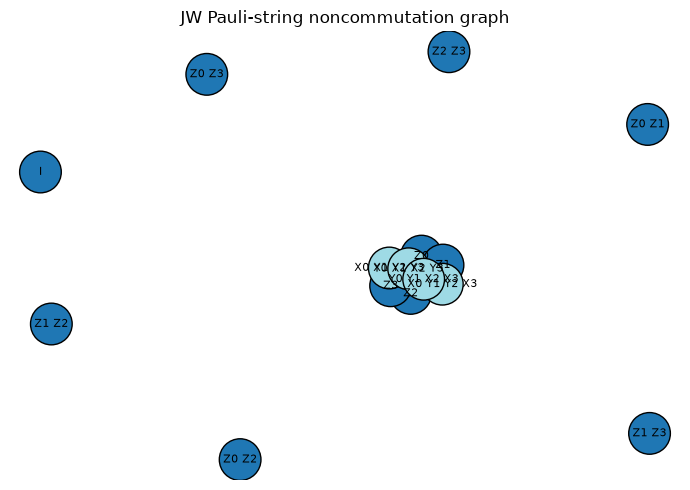

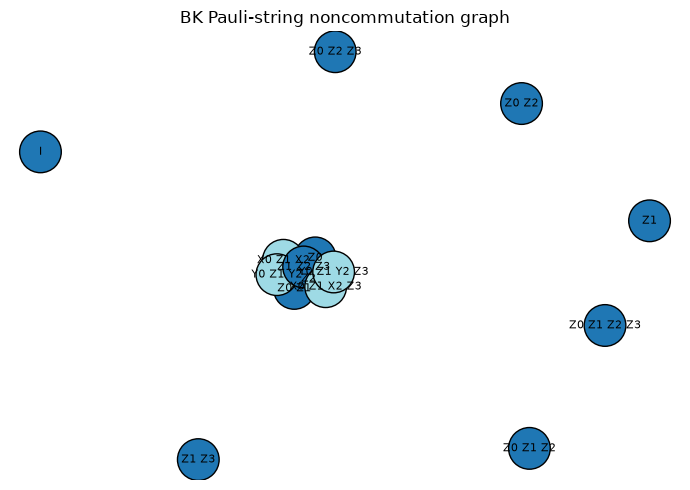

In [8]:
# Cell 4: Draw JW and BK Pauli-string noncommutation graphs


def draw_pauli_graph(Gp, coloring, title):
    plt.figure(figsize=(7, 5))

    pos = nx.spring_layout(Gp, seed=7)
    node_colors = [coloring[node] for node in Gp.nodes()]
    labels = {node: Gp.nodes[node]["label"] for node in Gp.nodes()}

    nx.draw_networkx_nodes(
        Gp,
        pos,
        node_color=node_colors,
        cmap=plt.cm.tab20,
        node_size=900,
        edgecolors="black",
    )
    nx.draw_networkx_edges(Gp, pos, alpha=0.45)
    nx.draw_networkx_labels(Gp, pos, labels=labels, font_size=8)

    plt.title(title)
    plt.axis("off")
    plt.tight_layout()
    plt.show()


draw_pauli_graph(G_JW_pauli, jw_pauli_coloring, "JW Pauli-string noncommutation graph")
draw_pauli_graph(G_BK_pauli, bk_pauli_coloring, "BK Pauli-string noncommutation graph")


In [5]:
# Cell 5: First-order Trotter error for Pauli-string orderings


def qubit_operator_matrix(qubit_op, n_qubits):
    return get_sparse_operator(qubit_op, n_qubits=n_qubits).toarray()


def exact_unitary(full_qubit_op, t, n_qubits):
    H = qubit_operator_matrix(full_qubit_op, n_qubits)
    return expm(-1j * t * H)


def first_order_trotter_unitary(term_ops, t, n_qubits):
    """
    term_ops[0] acts first on the state.
    """
    dim = 2 ** n_qubits
    U = np.eye(dim, dtype=complex)

    for op in term_ops:
        Hk = qubit_operator_matrix(op, n_qubits)
        U = expm(-1j * t * Hk) @ U

    return U


def ground_state_vector(full_qubit_op, n_qubits):
    H = qubit_operator_matrix(full_qubit_op, n_qubits)
    eigenvalues, eigenvectors = np.linalg.eigh(H)
    return eigenvectors[:, np.argmin(eigenvalues)]


def trotter_errors(full_qubit_op, term_ops, t, n_qubits):
    U_exact = exact_unitary(full_qubit_op, t, n_qubits)
    U_trot = first_order_trotter_unitary(term_ops, t, n_qubits)

    operator_error = norm(U_trot - U_exact, ord=2)

    psi0 = ground_state_vector(full_qubit_op, n_qubits)
    state_error = norm((U_trot - U_exact) @ psi0, ord=2)

    return operator_error, state_error


def color_order_from_groups(color_groups):
    order = []
    for color in sorted(color_groups):
        order.extend(color_groups[color])
    return order


jw_default_order = list(range(len(jw_terms)))
bk_default_order = list(range(len(bk_terms)))

jw_color_order = color_order_from_groups(jw_pauli_color_groups)
bk_color_order = color_order_from_groups(bk_pauli_color_groups)

experiments = [
    {
        "mapping": "JW",
        "ordering": "default_Pauli_order",
        "full_op": H_JW,
        "term_ops": [jw_terms[i]["operator"] for i in jw_default_order],
    },
    {
        "mapping": "JW",
        "ordering": "Pauli_graph_color_order",
        "full_op": H_JW,
        "term_ops": [jw_terms[i]["operator"] for i in jw_color_order],
    },
    {
        "mapping": "BK",
        "ordering": "default_Pauli_order",
        "full_op": H_BK,
        "term_ops": [bk_terms[i]["operator"] for i in bk_default_order],
    },
    {
        "mapping": "BK",
        "ordering": "Pauli_graph_color_order",
        "full_op": H_BK,
        "term_ops": [bk_terms[i]["operator"] for i in bk_color_order],
    },
]

t_values = [0.05, 0.10, 0.25, 0.50, 1.00]

rows = []

for exp in experiments:
    for t in t_values:
        op_err, state_err = trotter_errors(
            exp["full_op"],
            exp["term_ops"],
            t=t,
            n_qubits=n_qubits,
        )

        rows.append(
            {
                "mapping": exp["mapping"],
                "ordering": exp["ordering"],
                "t": t,
                "operator_norm_error": op_err,
                "ground_state_error": state_err,
                "number_of_exponentials": len(exp["term_ops"]),
            }
        )

pauli_trotter_error_df = pd.DataFrame(rows)

print("=== Pauli-string Trotter errors ===")
display(pauli_trotter_error_df)


=== Pauli-string Trotter errors ===


,mapping,ordering,t,operator_norm_error,ground_state_error,number_of_exponentials
0,JW,default_Pauli_order,0.05,0.000357,0.000357,15
1,JW,default_Pauli_order,0.10,0.001427,0.001427,15
2,JW,default_Pauli_order,0.25,0.008888,0.008888,15
3,JW,default_Pauli_order,0.50,0.035069,0.035069,15
4,JW,default_Pauli_order,1.00,0.132779,0.132779,15
5,JW,Pauli_graph_color_order,0.05,0.000357,0.000357,15
6,JW,Pauli_graph_color_order,0.10,0.001427,0.001427,15
7,JW,Pauli_graph_color_order,0.25,0.008888,0.008888,15
8,JW,Pauli_graph_color_order,0.50,0.035069,0.035069,15
9,JW,Pauli_graph_color_order,1.00,0.132779,0.132779,15


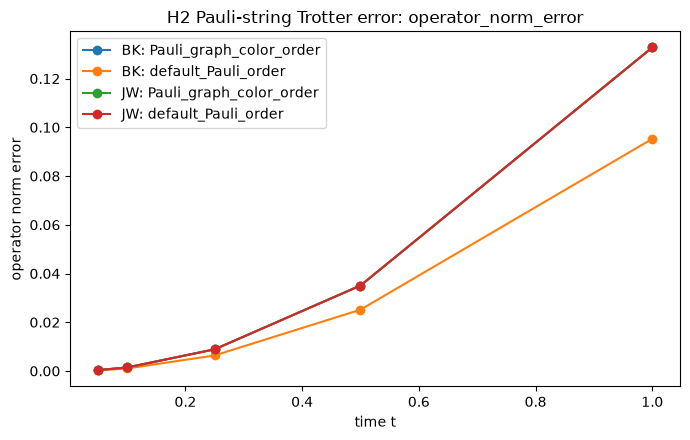

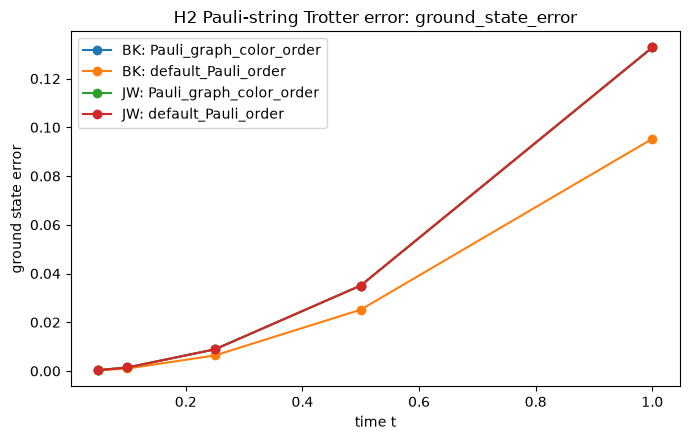

In [6]:
# Cell 6: Plot Pauli-string Trotter-error curves

for metric in ["operator_norm_error", "ground_state_error"]:
    plt.figure(figsize=(7, 4.5))

    for (mapping, ordering), subdf in pauli_trotter_error_df.groupby(["mapping", "ordering"]):
        subdf = subdf.sort_values("t")
        plt.plot(
            subdf["t"],
            subdf[metric],
            marker="o",
            label=f"{mapping}: {ordering}",
        )

    plt.xlabel("time t")
    plt.ylabel(metric.replace("_", " "))
    plt.title(f"H2 Pauli-string Trotter error: {metric}")
    plt.legend()
    plt.tight_layout()
    plt.show()


=== Fermionic graph vs Pauli-string graph ===


,graph_type,vertices,noncommuting_pairs_edges,colors_commuting_groups
0,Fermionic terms,13,12,2
1,JW Pauli strings,15,16,2
2,BK Pauli strings,15,16,2


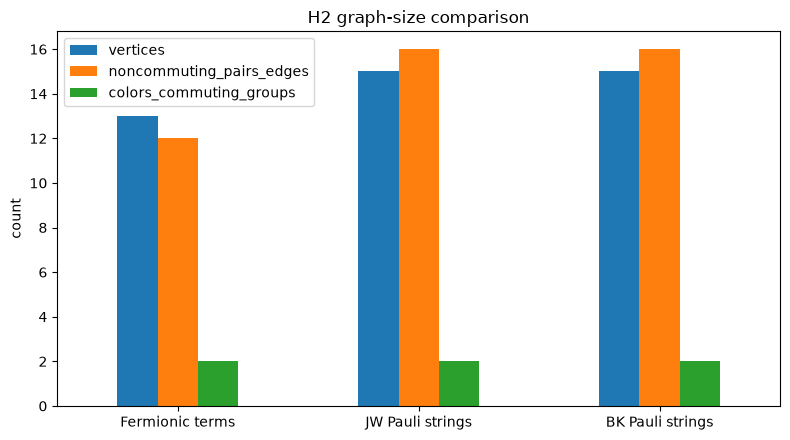

In [7]:
# Cell 7: Compare fermionic-term graph size with Pauli-string graph size
#
# This gives the implementation motivation:
# the fermionic graph can have fewer scheduling objects than the Pauli-string graph.


def fermionic_commutator(A, B, tol=1e-12):
    C = normal_ordered(A * B - B * A)
    C.compress(abs_tol=tol)
    return C


def fermionic_commute(A, B, tol=1e-12):
    return len(fermionic_commutator(A, B, tol=tol).terms) == 0


def build_fermionic_noncommutation_graph(fermionic_terms):
    Gf = nx.Graph(name="fermionic term noncommutation graph")

    for i, T in enumerate(fermionic_terms):
        Gf.add_node(i, label=f"T_{i}", operator=T)

    for i, j in combinations(Gf.nodes(), 2):
        if not fermionic_commute(Gf.nodes[i]["operator"], Gf.nodes[j]["operator"]):
            Gf.add_edge(i, j)

    return Gf


G_fermionic = build_fermionic_noncommutation_graph(hermitian_terms)
fermionic_coloring, fermionic_color_groups = color_graph(G_fermionic)

comparison_df = pd.DataFrame(
    [
        {
            "graph_type": "Fermionic terms",
            "vertices": G_fermionic.number_of_nodes(),
            "noncommuting_pairs_edges": G_fermionic.number_of_edges(),
            "colors_commuting_groups": len(fermionic_color_groups),
        },
        {
            "graph_type": "JW Pauli strings",
            "vertices": G_JW_pauli.number_of_nodes(),
            "noncommuting_pairs_edges": G_JW_pauli.number_of_edges(),
            "colors_commuting_groups": len(jw_pauli_color_groups),
        },
        {
            "graph_type": "BK Pauli strings",
            "vertices": G_BK_pauli.number_of_nodes(),
            "noncommuting_pairs_edges": G_BK_pauli.number_of_edges(),
            "colors_commuting_groups": len(bk_pauli_color_groups),
        },
    ]
)

print("=== Fermionic graph vs Pauli-string graph ===")
display(comparison_df)

ax = comparison_df.plot(
    x="graph_type",
    y=["vertices", "noncommuting_pairs_edges", "colors_commuting_groups"],
    kind="bar",
    figsize=(8, 4.5),
)
ax.set_xlabel("")
ax.set_ylabel("count")
ax.set_title("H2 graph-size comparison")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## Interpretation

The Pauli-string notebook is the baseline implementation.

The key comparison is not only the Trotter error, but also the number of scheduling objects:

- Fermionic graph vertices are Hermitian fermionic terms.
- Pauli graph vertices are individual Pauli strings after JW or BK mapping.
- One fermionic term can map to multiple Pauli strings, so the Pauli-string scheduling problem can be larger.

This is the practical motivation for studying fermionic-term commutation graphs before mapping.
